# 09-Query Transformation (HyDE)

In Lesson 08, we perfected our retrieval pipeline by deploying a Cross-Encoder. We can now evaluate candidate documents with deep token-to-token cross-attention, rescuing highly relevant documents from the bottom of the pile.

However, all of our engineering thus far has assumed one thing: **The user writes a good query.**

In reality, users are notoriously lazy. An Enterprise database might contain a beautifully written, 10-page diagnostic manual on resolving "Network Protocol TCP/IP Handshake Timeouts".
If the user's query is just *"wifi broke blinking red light"*, the retrieval system will mathematically fail. The semantic distance between the user's short, informal complaint and the database's long, formal declarative solution is too vast.

To solve the "Garbage In, Garbage Out" (GIGO) problem, we must intercept the user's input before it reaches the Vector Database. We must master the mathematics of **Hypothetical Document Embeddings (HyDE)**.

Let's set up our environment to engineer the physics of Query Transformation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Query Transformation Environment Ready.")

✅ Systems Architecture & Query Transformation Environment Ready.


# 1. The Semantic Spatial Mismatch

Embedding models (like `text-embedding-3-small`) are typically trained using contrastive learning on vast corpora of text. Because of this, they mathematically cluster text based on **vocabulary, tone, and structure**.

This creates a geometric problem:

* **The Query ($q$)**: "How do I reset the server?" (Short, interrogative, informal).
* **The Target Document ($d$)**: "To initiate a factory reset on the X900 server rack, the administrator must hold the hardware initialization button for 15 seconds." (Long, declarative, formal).

In a high-dimensional vector space, $q$ and $d$ often occupy completely different neighborhoods. Queries cluster with other queries, and manuals cluster with other manuals.


# 2. The Mathematics of HyDE

In 2022, researchers at Carnegie Mellon University introduced **HyDE**. The premise is brilliantly counter-intuitive: **We use an LLM to intentionally hallucinate an answer, and then we search the database using the hallucination.**

### The Pipeline Calculus:

1. **Instruction Generation**: We pass the user's weak query $q$ into a Generative LLM with a strict prompt: *"Write a paragraph answering this question."*
2. **The Hallucination ($h$)**: The LLM generates a hypothetical document. Crucially, *we do not care if the LLM's facts are completely wrong*. We only care that the LLM generates a text block with the correct **vocabulary, tone, and declarative structure** of a real answer.
3. **The Embedding Mapping ($f$)**: We pass the hypothetical document $h$ into our Bi-Encoder to generate a Dense Vector, completely discarding the original user query $q$.

$$\mathbf{v}_h = f(h)$$


4. **Retrieval**: We execute a standard Cosine Similarity search in the Vector Database using $\mathbf{v}_h$ to find the true, factually correct document $d$.

$$\text{Score}(h, d) = \cos(\mathbf{v}_h, \mathbf{v}_d)$$



By embedding $h$ instead of $q$, we teleport the search vector across the semantic gap, dropping it directly into the neighborhood of declarative manuals.

# 3. Architecting the HyDE Pipeline

Let's simulate this transformation pipeline. We will mock an LLM generating a hallucinated response, and demonstrate how its vocabulary aligns perfectly with the target document.

In [2]:
# --- 🧠 The Query Transformation Engine (HyDE) ---

class MockGenerativeLLM:
    """Simulates a fast, cheap LLM used strictly for query expansion (e.g., Llama-3 8B)."""
    def generate_hypothetical_document(self, query: str) -> str:
        print(f"🤖 [LLM] Hallucinating a hypothetical answer for: '{query}'...")
        # The LLM doesn't know the exact company policy, so it guesses the standard IT process.
        hypothetical_doc = (
            "To resolve a blinking red light on the localized network router, "
            "the hardware must be power-cycled. Disconnect the primary AC power cable, "
            "wait for 30 seconds to clear the internal cache, and reconnect the power supply. "
            "If the light remains red, the ISP connection may be severed."
        )
        return hypothetical_doc

# 1. The User's Terrible Query
raw_user_query = "wifi broke blinking red light"

# 2. The True Enterprise Document (Sitting in the Vector DB)
true_document = (
    "Cisco Meraki MX68 Hardware Diagnostic: A continuous blinking red status LED indicates "
    "a failure to establish a secure VPN handshake with the primary WAN. "
    "Administrators must execute a hard power-cycle by removing the AC adapter for 30 seconds."
)

print(f"--- 📉 The Baseline Problem ---")
print(f"User Query: '{raw_user_query}'")
print(f"Target Doc: '{true_document}'")
print("Notice the severe vocabulary mismatch. 'wifi' vs 'WAN', 'broke' vs 'failure'.\n")

# 3. Execute HyDE
llm = MockGenerativeLLM()
hypothetical_document = llm.generate_hypothetical_document(raw_user_query)

print(f"--- 📈 The HyDE Transformation ---")
print(f"Hypothetical Doc: '{hypothetical_document}'")

print("\n--- 💡 Engineering Insight ---")
print("Look at the overlap between the Hallucination and the True Document!")
print("Both use the phrases: 'power-cycle', 'AC', '30 seconds'. By embedding the Hallucination, we are searching the Vector Database using the exact terminology of an IT manual, rather than the slang of a frustrated user. The Vector Search will now easily find the correct Cisco manual.")

--- 📉 The Baseline Problem ---
User Query: 'wifi broke blinking red light'
Target Doc: 'Cisco Meraki MX68 Hardware Diagnostic: A continuous blinking red status LED indicates a failure to establish a secure VPN handshake with the primary WAN. Administrators must execute a hard power-cycle by removing the AC adapter for 30 seconds.'
Notice the severe vocabulary mismatch. 'wifi' vs 'WAN', 'broke' vs 'failure'.

🤖 [LLM] Hallucinating a hypothetical answer for: 'wifi broke blinking red light'...
--- 📈 The HyDE Transformation ---
Hypothetical Doc: 'To resolve a blinking red light on the localized network router, the hardware must be power-cycled. Disconnect the primary AC power cable, wait for 30 seconds to clear the internal cache, and reconnect the power supply. If the light remains red, the ISP connection may be severed.'

--- 💡 Engineering Insight ---
Look at the overlap between the Hallucination and the True Document!
Both use the phrases: 'power-cycle', 'AC', '30 seconds'. By embedding

# 4. Visualizing the Spatial Translation

To mathematically prove why this works, let's visualize the High-Dimensional Vector Space. We will plot the geometric coordinates of the User Query, the Hallucinated Document, and the True Document.

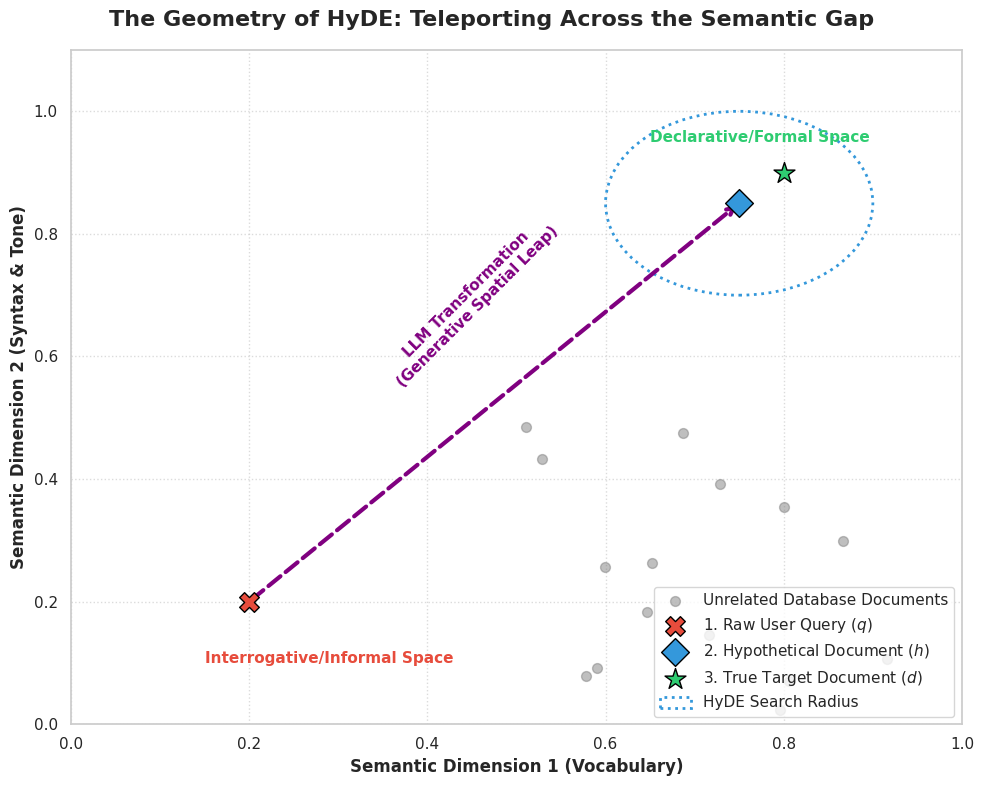


--- 💡 Engineering Insight ---
Look at the Red 'X' (The User Query). If you do a standard vector search from the Red X, the Green Star (The Answer) is too far away. The search radius will retrieve the gray irrelevant documents instead.
By using an LLM to generate the Blue Diamond (HyDE), we physically teleport our starting point across the map. Now, when we draw our search radius around the Blue Diamond, we instantly capture the Green Star. We have mathematically bypassed the vocabulary mismatch.


In [3]:
# Simulate Vector Coordinates in 2D space for visualization
np.random.seed(42)

# Queries cluster in the bottom left
query_vector = np.array([0.2, 0.2])

# True manuals cluster in the top right
true_doc_vector = np.array([0.8, 0.9])

# The HyDE document bridges the gap, landing near the manuals
hyde_vector = np.array([0.75, 0.85])

# Unrelated documents (e.g., HR manuals, Marketing materials)
unrelated_docs = np.random.rand(15, 2) * 0.5 + np.array([0.5, 0.0])

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("The Geometry of HyDE: Teleporting Across the Semantic Gap", fontsize=16, fontweight='bold')

# Plot Unrelated Docs
ax.scatter(unrelated_docs[:, 0], unrelated_docs[:, 1], c='gray', s=50, alpha=0.5, label="Unrelated Database Documents")

# Plot the primary actors
ax.scatter(query_vector[0], query_vector[1], c='#e74c3c', s=200, marker='X', edgecolors='black', zorder=5, label="1. Raw User Query ($q$)")
ax.scatter(hyde_vector[0], hyde_vector[1], c='#3498db', s=200, marker='D', edgecolors='black', zorder=5, label="2. Hypothetical Document ($h$)")
ax.scatter(true_doc_vector[0], true_doc_vector[1], c='#2ecc71', s=250, marker='*', edgecolors='black', zorder=5, label="3. True Target Document ($d$)")

# Draw the spatial translation arrows
ax.annotate("", xy=hyde_vector, xytext=query_vector, 
            arrowprops=dict(arrowstyle="->", color="purple", lw=3, linestyle="dashed"))

# Draw the Cosine Similarity Search Radius from the new HyDE vector
circle = plt.Circle(hyde_vector, 0.15, color='#3498db', fill=False, linestyle=':', linewidth=2, label="HyDE Search Radius")
ax.add_patch(circle)

# Labels and styling
ax.text(0.45, 0.55, "LLM Transformation\n(Generative Spatial Leap)", color="purple", fontsize=11, fontweight='bold', ha='center', rotation=45)
ax.text(0.15, 0.1, "Interrogative/Informal Space", color="#e74c3c", fontsize=11, fontweight='bold')
ax.text(0.65, 0.95, "Declarative/Formal Space", color="#2ecc71", fontsize=11, fontweight='bold')

ax.set_xlabel("Semantic Dimension 1 (Vocabulary)", fontsize=12, fontweight='bold')
ax.set_ylabel("Semantic Dimension 2 (Syntax & Tone)", fontsize=12, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, linestyle=':', alpha=0.7)

plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Red 'X' (The User Query). If you do a standard vector search from the Red X, the Green Star (The Answer) is too far away. The search radius will retrieve the gray irrelevant documents instead.")
print("By using an LLM to generate the Blue Diamond (HyDE), we physically teleport our starting point across the map. Now, when we draw our search radius around the Blue Diamond, we instantly capture the Green Star. We have mathematically bypassed the vocabulary mismatch.")

## Real-World Use Case or Analogy:

Think of HyDE like working with a **Police Sketch Artist**:

* **Standard Vector Search**: A witness runs into the police station and says, *"He looked scary, had a big nose, and was wearing a hat."* (The Query). The police take that exact quote, go to the filing cabinet, and try to find a mugshot with the literal words "scary big nose hat" written on the back. They fail.
* **HyDE (The Sketch Artist)**: The witness says, *"He looked scary, had a big nose, and was wearing a hat."* The police don't search the database yet. Instead, they sit the witness down with a **Sketch Artist** (The Generative LLM). The artist uses those vague words to draw a highly detailed, professional, standardized composite portrait (The Hypothetical Document).
* The police take that professional portrait and run it through their facial recognition database (The Vector Search). The system matches the sketch to a real mugshot (The True Document) perfectly, because it is comparing an image to an image, rather than a vague quote to an image.